In [1]:
import matplotlib.pyplot as plt

"""
Step 1: Get the topological order of DAGs.
Step 2: Generate the scenario.
Step 3: Run the three algorithms and compare the results.
"""

from models.scheduler.dpe import DPE
from models.scheduler.heft import HEFT
from models.utils.dataset import *
from models.utils.scenario import *

In [2]:
# 采集数据，并对 task 进行拓扑排序
sample_jobs()
get_topological_order()

Dataset (batch_task.csv & batch_instance.csv) is already selected.
Jobs' topological order has been obtained.



The connected graph of edge servers (represented by adjacent matrix):
array([[1., 1., 1., 0.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [0., 1., 1., 1.]])

====> throughput of each link <====
array([[-1., 34., 66., -1.],
       [34., -1., 39., 70.],
       [66., 39., -1., 30.],
       [-1., 70., 30., -1.]])

====> processing power of edge server <====
array([ 7,  9,  8, 12])

====> All simple paths between any two server <====
[[[[0]],
  [[0, 1], [0, 2, 1], [0, 2, 3, 1]],
  [[0, 1, 2], [0, 1, 3, 2], [0, 2]],
  [[0, 1, 2, 3], [0, 1, 3], [0, 2, 1, 3], [0, 2, 3]]],
 [[[1, 0], [1, 2, 0], [1, 3, 2, 0]],
  [[1]],
  [[1, 0, 2], [1, 2], [1, 3, 2]],
  [[1, 0, 2, 3], [1, 2, 3], [1, 3]]],
 [[[2, 0], [2, 1, 0], [2, 3, 1, 0]],
  [[2, 0, 1], [2, 1], [2, 3, 1]],
  [[2]],
  [[2, 0, 1, 3], [2, 1, 3], [2, 3]]],
 [[[3, 1, 0], [3, 1, 2, 0], [3, 2, 0], [3, 2, 1, 0]],
  [[3, 1], [3, 2, 0, 1], [3, 2, 1]],
  [[3, 1, 0, 2], [3, 1, 2], [3, 2]],
  [[3]]]]

Getting makespan for 100 jobs by DPE al

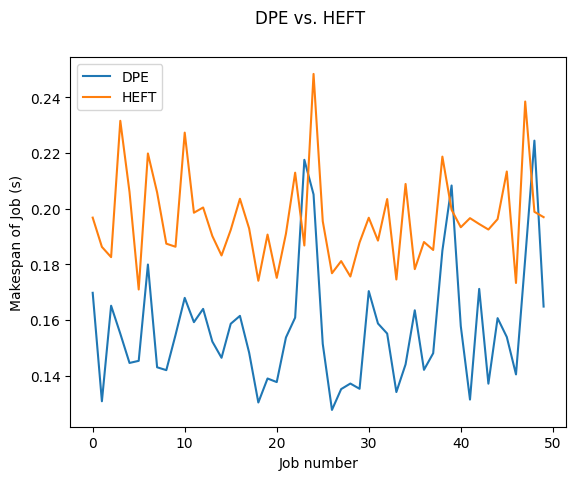

In [3]:
dpe_makespan = []
heft_makespan = []

for job_num_chosen in range(50):
    # 生成边缘计算场景
    G, bw, pp = generate_scenario()
    print_scenario(G, bw, pp)
    simple_paths = get_simple_paths(G)
    print_simple_paths(simple_paths)
    reciprocals_list, proportions_list = get_ratio(simple_paths, bw)
    pp_required, data_stream = set_funcs()

    # 进行算法对比 DPE
    dpe = DPE(G, bw, pp, simple_paths, reciprocals_list, proportions_list, pp_required, data_stream)
    # start = datetime.datetime.now()
    cpu_earliest_finish_time_all_dpe, task_deployment_all_dpe, \
        cpu_task_mapping_list_all_dpe, task_start_time_all_dpe, makespan_avg_dpe \
        = dpe.get_response_time(sorted_job_path=para.get("batch_task_topological_order_path"))
    # print(task_deployment_all_dpe)
    # end = datetime.datetime.now()
    # print('Computer\'s running time:', (end - start).microseconds, 'microseconds')
    # show_DAG()  # TODO
    # scheduling_result = SchedulingResult(cpu_earliest_finish_time_all_dpe,
    #                                      task_deployment_all_dpe,
    #                                      cpu_task_mapping_list_all_dpe,
    #                                      task_start_time_all_dpe,
    #                                      job_num_chosen)
    # scheduling_result.print()
    dpe_makespan.append(makespan_avg_dpe)

    # 进行算法对比 HEFT
    heft = HEFT(G, bw, pp, simple_paths, reciprocals_list, proportions_list, pp_required, data_stream)
    # start = datetime.datetime.now()
    cpu_task_mapping_list_all, task_deployment_all, makespan_avg_heft \
        = heft.get_response_time(sorted_job_path=para.get("batch_task_topological_order_path"))
    # end = datetime.datetime.now()
    # print('Computer\'s running time:', (end - start).microseconds, 'microseconds')
    # print('\nThe finish time of each task on the chosen cpu for job #%d:' % job_num_chosen)
    # pprint.pprint(cpu_task_mapping_list_all[job_num_chosen])
    heft_makespan.append(makespan_avg_heft)

plt.plot(range(50), dpe_makespan, label='DPE')
plt.plot(range(50), heft_makespan, label='HEFT')
plt.suptitle('DPE vs. HEFT')
plt.ylabel("Makespan of Job (s)")
plt.xlabel("Job number")
plt.legend()
plt.show()

In [1]:
import numpy as np

group1 = [0.604580826469882, 0.75, 0.4787038299032302, 0.8029556650246303, 0.48193760262725777,
          1.1324500087618528]  # DPE
group2 = [0.62651628731089, 0.9162464222434239, 0.5781995365953387, 0.7614488210440236, 0.41666666666666663,
          1.0090344438170524]  # HEFT
group3 = [0.58112512232, 0.85221254625775, 0.44668756554562123, 0.602355646633, 0.4063225668556465,
          0.956542321523]  # OURS

dpe = np.sum(group1)
heft = np.sum(group2)
ours = np.sum(group3)


def get_score(a, b):
    return (a - b) / b


print(get_score(ours, dpe))
print(get_score(ours, heft))

-0.0953699477023042
-0.1074406583330706
